# MouseBrain Proximity And Enrichment Figure Reproduction

This notebook keeps only the material needed for the two Microglia proximity panels and the final stGP2 GO/cell-signature enrichment panel. It recomputes the required statistics from the stGP/QC inputs and local gene-set files, without reading cached proximity or enrichment result tables.


In [1]:
%matplotlib inline

import json
import os
import sys
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

PROJECT_DIR = Path.cwd()
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))

import utils
from plots import set_nature_style
set_nature_style()

In [2]:
CELLTYPE = "Microglia"
PROGRAM_ID = 2
PROGRAM_INDEX = PROGRAM_ID - 1
PROGRAM_LABEL = f"stGP{PROGRAM_ID}"

safe_ct = utils.safe_name(CELLTYPE)
prox_csv_dir = utils.RESULTS_PROXIMITY / safe_ct
enrich_csv_dir = utils.RESULTS_ENRICHMENT / safe_ct
fig_dir = utils.FIGURES_ROOT / safe_ct
fig_dir.mkdir(parents=True, exist_ok=True)

def save_pair(fig, stem, *, out_dir=fig_dir, dpi=400, bbox_inches="tight", pad_inches=0.05):
    png = out_dir / f"{stem}.png"
    pdf = out_dir / f"{stem}.pdf"
    fig.savefig(png, dpi=dpi, bbox_inches=bbox_inches, pad_inches=pad_inches)
    fig.savefig(pdf, bbox_inches=bbox_inches, pad_inches=pad_inches)
    display(fig)
    plt.close(fig)
    return png, pdf

## 1. Load target stGP scores and all-cell QC coordinates

In [3]:
adata_target = utils.load_target_data(CELLTYPE, utils.RESULTS_STGP)
target = utils.extract_target_arrays(adata_target)
regions = sorted(set(target["region"].tolist()))
program_k = PROGRAM_INDEX
k_label = target["program_labels"][program_k]

print(f"Target: {len(target['age']):,} {CELLTYPE} cells")
print(f"Using program: {k_label} (0-based index {program_k})")
print(f"Regions: {regions}")

adata_all = sc.read_h5ad(str(utils.DATA_QC))
glob = utils.extract_global_arrays(adata_all)
print(f"All QC cells: {adata_all.n_obs:,}")

display(pd.DataFrame({
    "program": target["program_labels"],
    "b_mean": target["B"].mean(axis=0),
    "b_sd": target["B"].std(axis=0),
}))


Target: 52,417 Microglia cells
Using program: stGP2 (0-based index 1)
Regions: ['CC/ACO', 'CTX', 'STR', 'VEN']


All QC cells: 981,750


,program,b_mean,b_sd
0,stGP1,-0.000025,2.349389
1,stGP2,0.109020,2.114655
2,stGP3,-0.133019,2.165237
3,stGP4,0.887728,2.202204


## 2. Proximity effect and regression

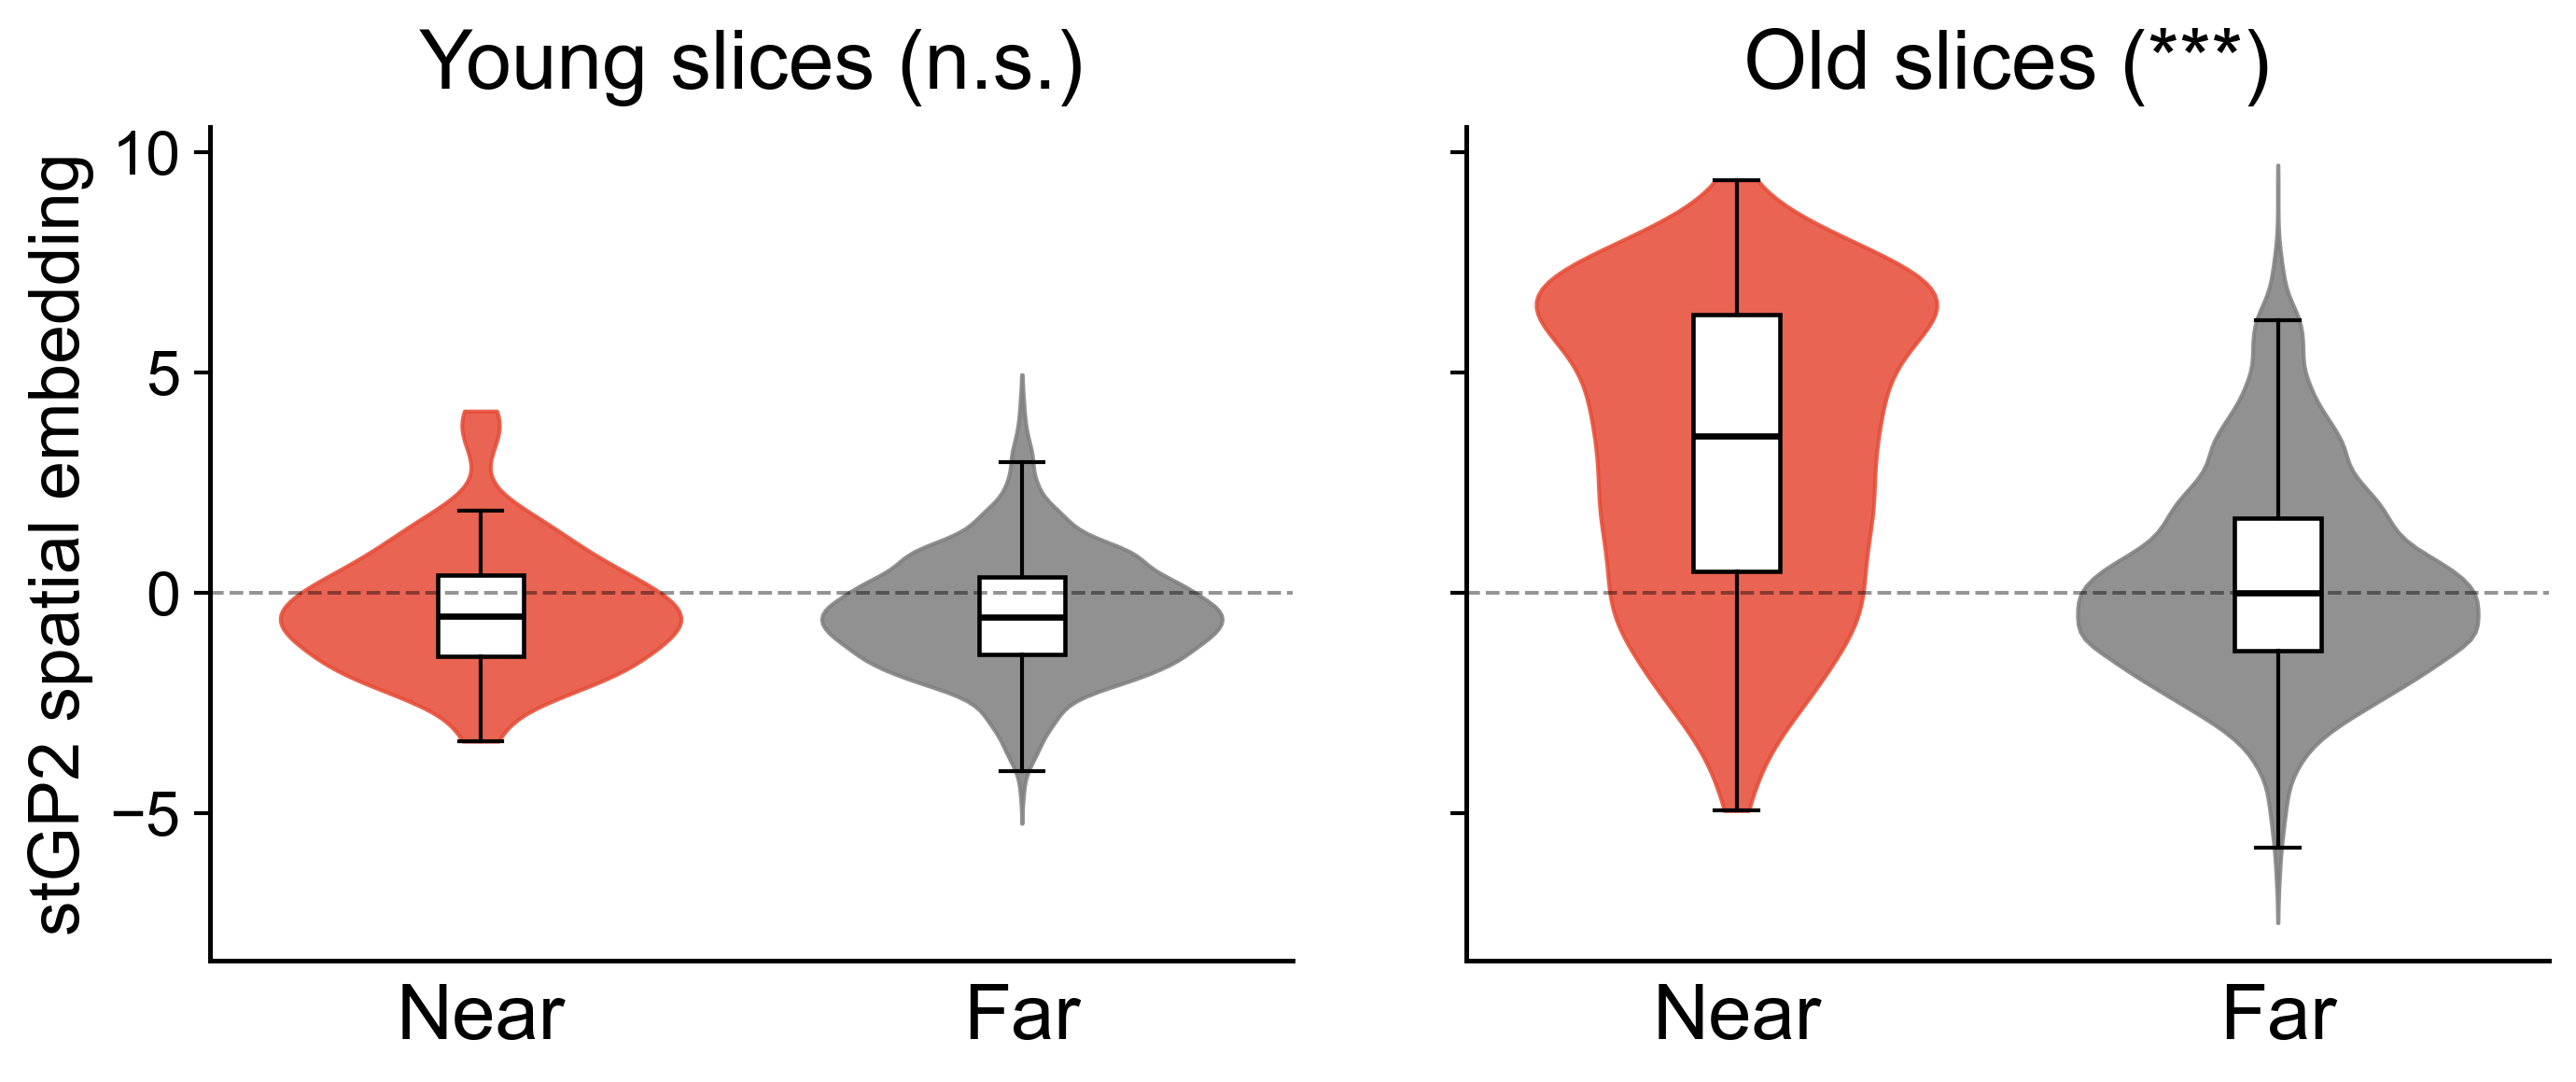

(PosixPath('Figures/Microglia/stGP2_near_far_violin_Tcell_horizontal.png'),
 PosixPath('Figures/Microglia/stGP2_near_far_violin_Tcell_horizontal.pdf'))

In [4]:
program_k = PROGRAM_INDEX
k_label = PROGRAM_LABEL
target_age = np.asarray(target["age"], dtype=float)
target_coord = np.asarray(target["coord"], dtype=float)
target_b = np.asarray(target["B"], dtype=float)
glob_age = np.asarray(glob["age"], dtype=float)
glob_ct = np.asarray(glob["ct"]).astype(str)
glob_coord = np.asarray(glob["coord"], dtype=float)

def near_far_for_ages(age_values, effector="T cell", r_near=50.0, r_far=150.0):
    near_vals, far_vals = [], []
    for age in age_values:
        eff_xy = glob_coord[(glob_age == age) & (glob_ct == effector)]
        blk = target_age == age
        if len(eff_xy) < 1 or blk.sum() < 10:
            continue
        d, _ = utils.cKDTree(eff_xy).query(target_coord[blk], k=1)
        near = d <= r_near
        far = d > r_far
        if near.sum() < 5 or far.sum() < 5:
            continue
        b = target_b[blk, program_k]
        near_vals.append(b[near])
        far_vals.append(b[far])
    if not near_vals:
        return None
    return np.concatenate(near_vals), np.concatenate(far_vals)

median_age = float(np.median(np.unique(target_age)))
age_groups = [
    (sorted(a for a in np.unique(target_age) if a < median_age), "Young slices"),
    (sorted(a for a in np.unique(target_age) if a >= median_age), "Old slices"),
]
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.65), sharey=True, constrained_layout=False)
fig.subplots_adjust(left=0.115, right=0.985, top=0.82, bottom=0.18, wspace=0.16)
for ax, (age_values, label) in zip(axes, age_groups):
    vals = near_far_for_ages(age_values)
    if vals is None:
        ax.text(0.5, 0.5, "Insufficient cells", transform=ax.transAxes, ha="center", va="center", fontsize=16, color="#777777")
        ax.set_axis_off()
        continue
    v_near, v_far = vals
    parts = ax.violinplot([v_near, v_far], positions=[0, 1], showmedians=False, showextrema=False, widths=0.74)
    for pc, color in zip(parts["bodies"], ["#E64B35", "#7F7F7F"]):
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(0.86)
    ax.boxplot([v_near, v_far], positions=[0, 1], widths=0.16, patch_artist=True,
               boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.1),
               medianprops=dict(color="black", linewidth=1.6), showfliers=False)
    pval = utils.mannwhitneyu(v_near, v_far, alternative="two-sided").pvalue
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Near", "Far"], fontsize=20)
    ax.set_title(f"{label} ({utils.p_to_stars(pval)})", fontsize=21, fontweight="normal", pad=10)
    ax.axhline(0, ls="--", color="black", alpha=0.42, linewidth=0.95)
    ax.tick_params(axis="y", labelsize=16, length=4, width=1.0)
    ax.tick_params(axis="x", length=0, pad=6)
axes[0].set_ylabel(f"{k_label} spatial embedding", fontsize=18)
axes[1].set_ylabel("")
save_pair(fig, f"{k_label}_near_far_violin_Tcell_horizontal")


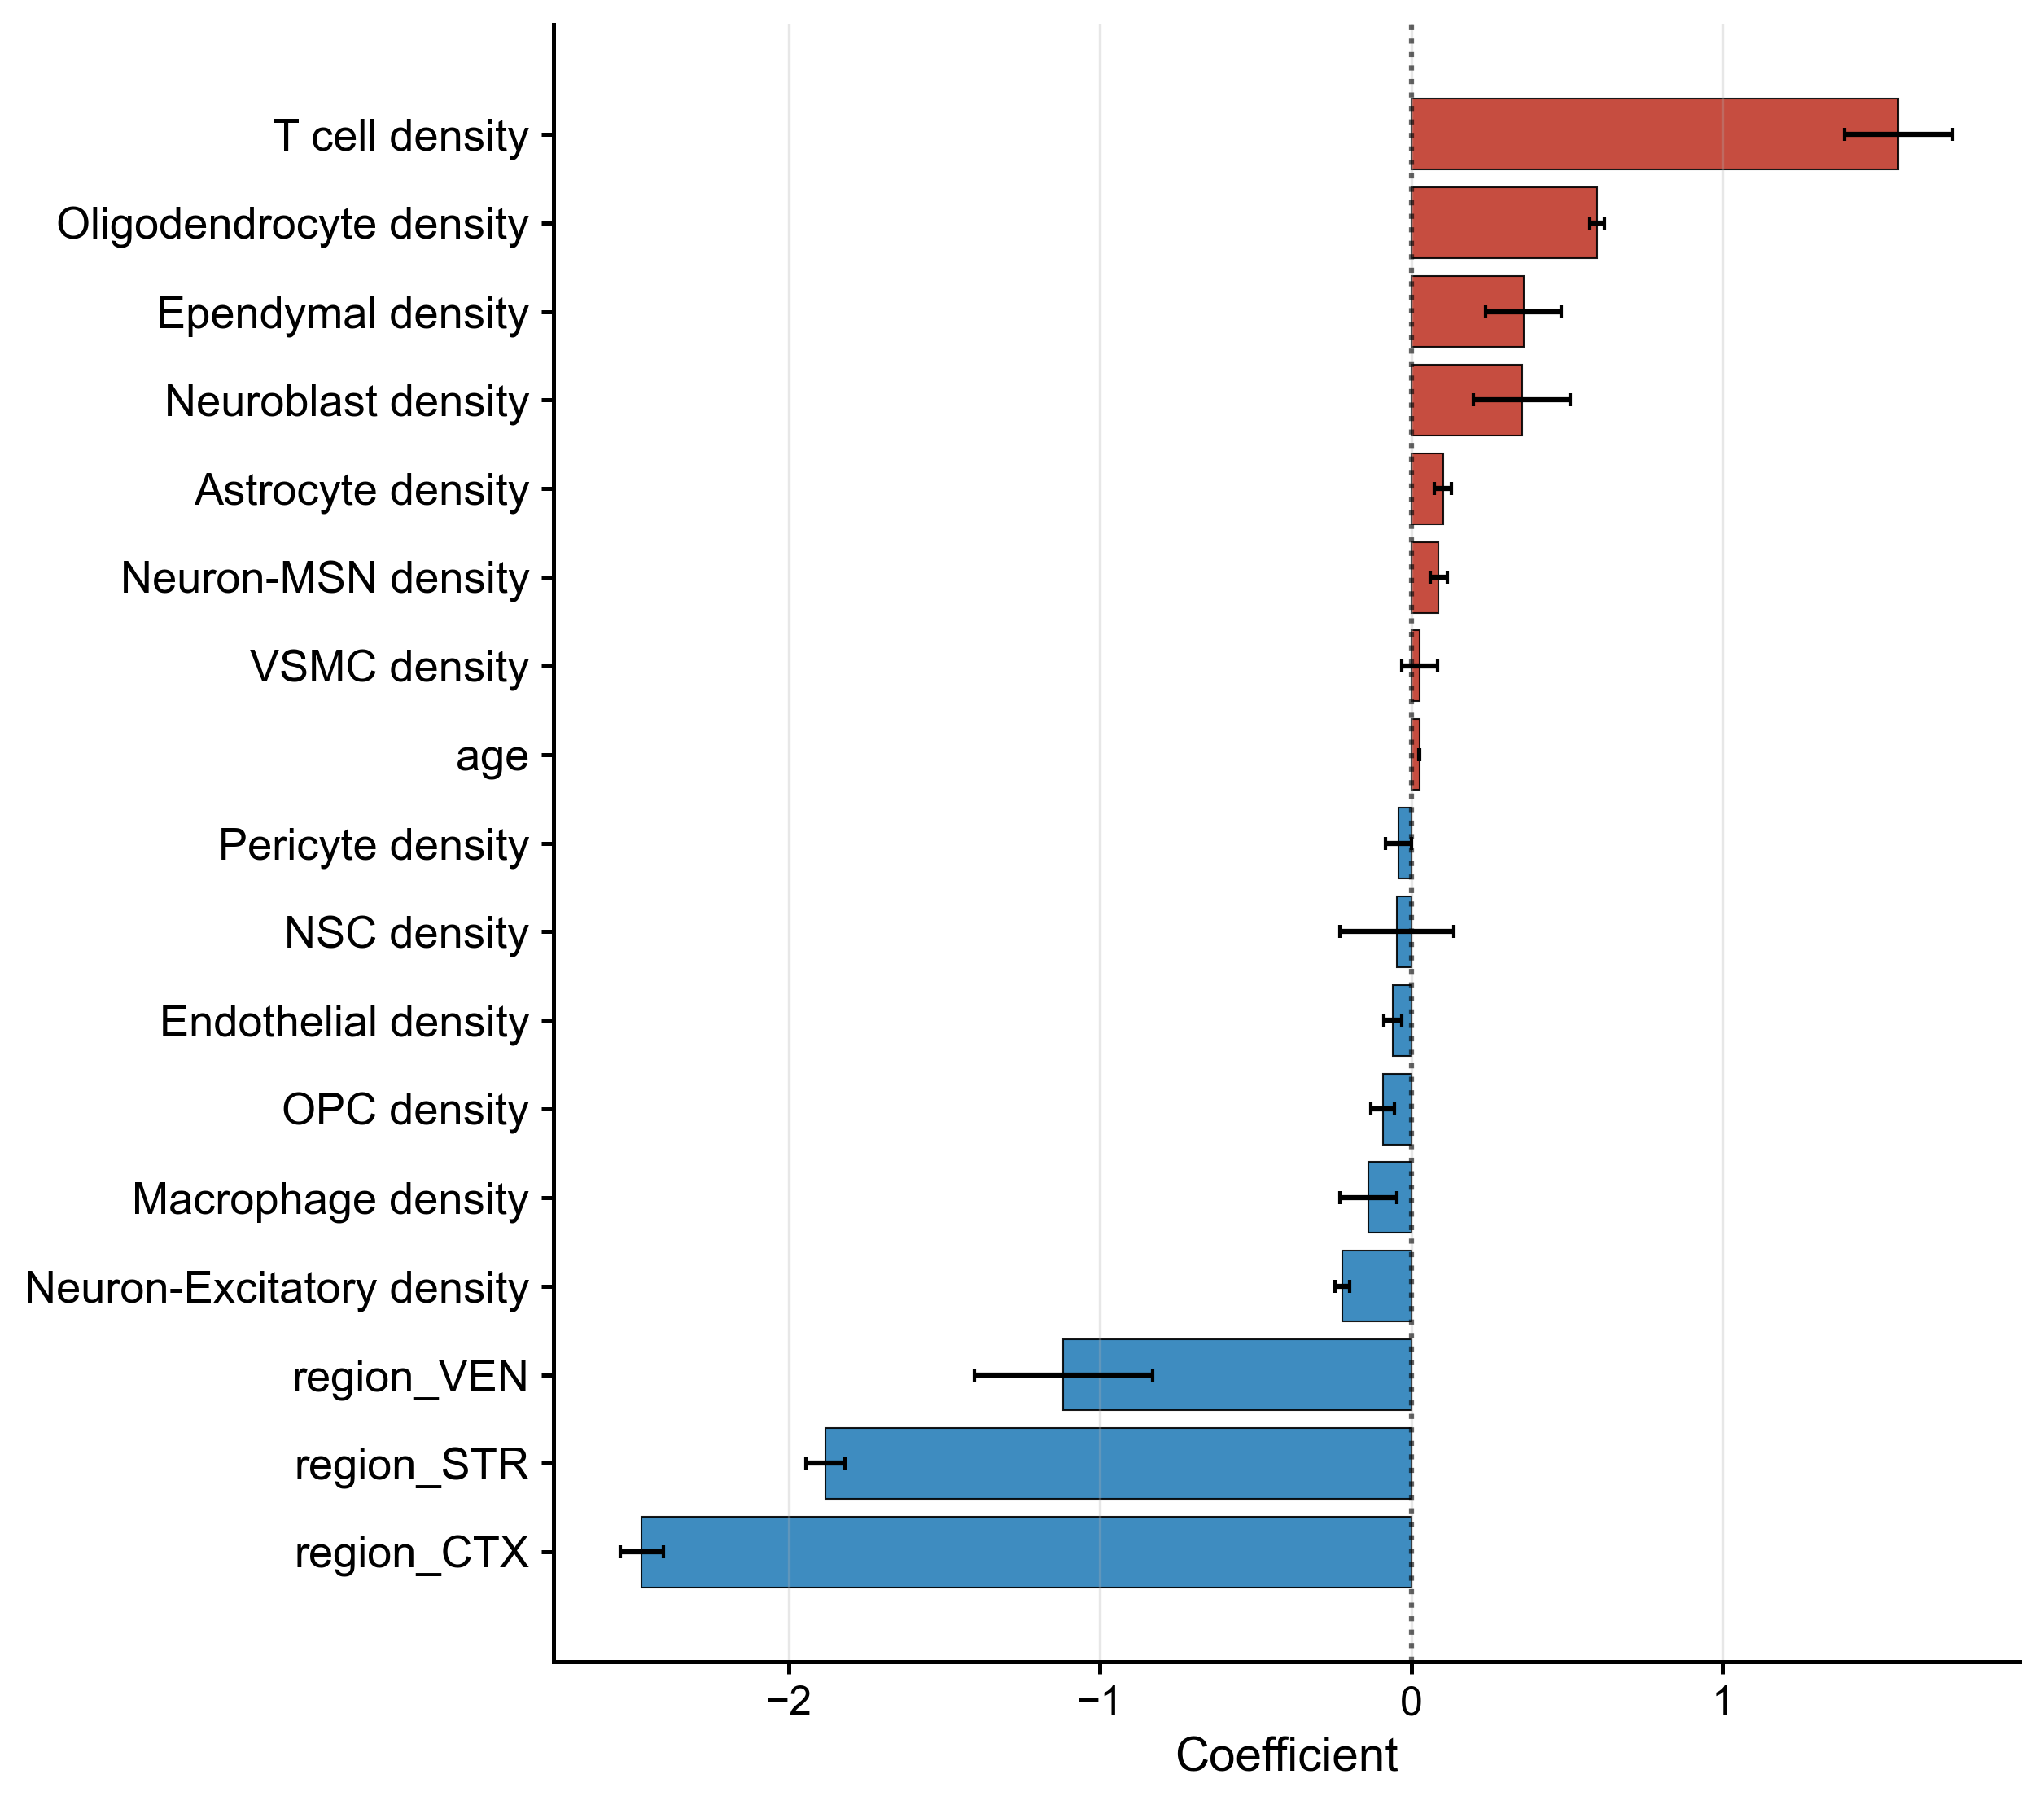

(PosixPath('Figures/Microglia/Microglia_stGP2_proximity_regression.png'),
 PosixPath('Figures/Microglia/Microglia_stGP2_proximity_regression.pdf'))

In [5]:
density_types = [ct for ct in utils.BASELINE_RUN_ORDER if ct != CELLTYPE]
log_density = utils.per_cell_log_density(target, glob, density_types)

y = np.asarray(target["B"][:, program_k], dtype=float)
age = np.asarray(target["age"], dtype=float)
reg = np.asarray(target["region"]).astype(str)

enc = utils.OneHotEncoder(sparse_output=False, drop="first")
R_oh = enc.fit_transform(reg.reshape(-1, 1))
R_names = [f"region_{c}" for c in enc.categories_[0][1:]]
density_names = [f"{ct} density" for ct in density_types]

X = np.column_stack([age, R_oh, log_density])
xnames = ["age"] + R_names + density_names

X1c = np.column_stack([np.ones(len(y)), X])
beta, *_ = np.linalg.lstsq(X1c, y, rcond=None)
yhat = X1c @ beta
resid = y - yhat
rss = float((resid ** 2).sum())
tss = float(((y - y.mean()) ** 2).sum())
r2 = 1 - rss / tss

sigma2 = rss / max(len(y) - X1c.shape[1], 1)
try:
    XtX_inv = np.linalg.inv(X1c.T @ X1c + 1e-8 * np.eye(X1c.shape[1]))
    se = np.sqrt(sigma2 * np.diag(XtX_inv))
except np.linalg.LinAlgError:
    se = np.full(len(beta), np.nan)

df_coef_full = pd.DataFrame(dict(name=["intercept"] + xnames, coef=beta, se=se))
meta = dict(
    n_predictors=int(len(xnames)),
    r2=float(r2),
    density_types=density_types,
    region_terms=R_names,
    age_terms=["age"],
    density_terms=density_names,
    notes=dict(
        density=f"<ct> density = log(1 + number of <ct> cells within {utils.DENS_R:g} microns)",
    ),
)

df_coef = df_coef_full[df_coef_full["name"] != "intercept"].copy().sort_values("coef", ascending=True)

y_pos = np.arange(len(df_coef))
colors = ["#c0392b" if v > 0 else "#2980b9" for v in df_coef["coef"]]
fig, ax = plt.subplots(figsize=(8.5, max(0.36 * int(meta["n_predictors"]) + 1.4, 5.5)))
ax.barh(
    y_pos,
    df_coef["coef"].to_numpy(float),
    xerr=1.96 * df_coef["se"].to_numpy(float),
    color=colors,
    edgecolor="black",
    lw=0.5,
    alpha=0.9,
    capsize=2,
)
ax.axvline(0, ls=":", color="black", alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_coef["name"], fontsize=13)
ax.set_xlabel("Coefficient", fontsize=14)
ax.tick_params(axis="x", labelsize=12)
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
save_pair(fig, f"Microglia_{k_label}_proximity_regression")

## 3. GO analysis and cell-signature enrichment

In [6]:
GENE_SET_COLLECTIONS = None
PADJ_THRESHOLD = 0.1
N_TOP = 6

gene_sets = utils._resolve_gene_sets(GENE_SET_COLLECTIONS, utils.DEFAULT_GENESETS_DIR)
W = utils._load_W(utils.RESULTS_STGP, CELLTYPE)
if k_label not in W.index.astype(str):
    raise ValueError(f"{k_label} not found in W programs: {W.index.astype(str).tolist()}")
W.index = W.index.astype(str)
background_genes = W.columns.astype(str).tolist()
stgp2_weights = W.loc[k_label].astype(float)
stgp2_positive_genes = stgp2_weights[stgp2_weights > 0].sort_values(ascending=False).index.astype(str).tolist()

print(f"Using {k_label}: {len(stgp2_positive_genes)} positive genes")
print(f"Gene-set collections: {list(gene_sets.keys())}")


Using stGP2: 15 positive genes
Gene-set collections: ['GO Biological process', 'GO Molecular Function', 'GO Cellular Component', 'Cell-type signatures']


,program,n_genes_input,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,gene_set
0,stGP2,15,m5.go.bp.v2026.1.Mm.symbols.gmt,Actin filament based process,1/16,0.690206,0.859212,1.271413,0.471395,Bst2,GO Biological process
1,stGP2,15,m5.go.bp.v2026.1.Mm.symbols.gmt,Activation of immune response,3/29,0.314568,0.690746,1.896604,2.193525,Pdcd1;Lag3;Ptprc,GO Biological process
2,stGP2,15,m5.go.bp.v2026.1.Mm.symbols.gmt,Adaptive immune response,6/46,0.066478,0.427312,2.795971,7.579551,Ptprc;H2-D1;Pdcd1;H2-K1;Lag3;B2m,GO Biological process
3,stGP2,15,m5.go.bp.v2026.1.Mm.symbols.gmt,Adaptive immune response based on somatic reco...,6/32,0.011399,0.260809,4.634558,20.736029,Ptprc;H2-D1;Pdcd1;H2-K1;Lag3;B2m,GO Biological process
4,stGP2,15,m5.go.bp.v2026.1.Mm.symbols.gmt,Alpha beta T cell activation,1/19,0.753931,0.891673,1.048462,0.296142,Ptprc,GO Biological process


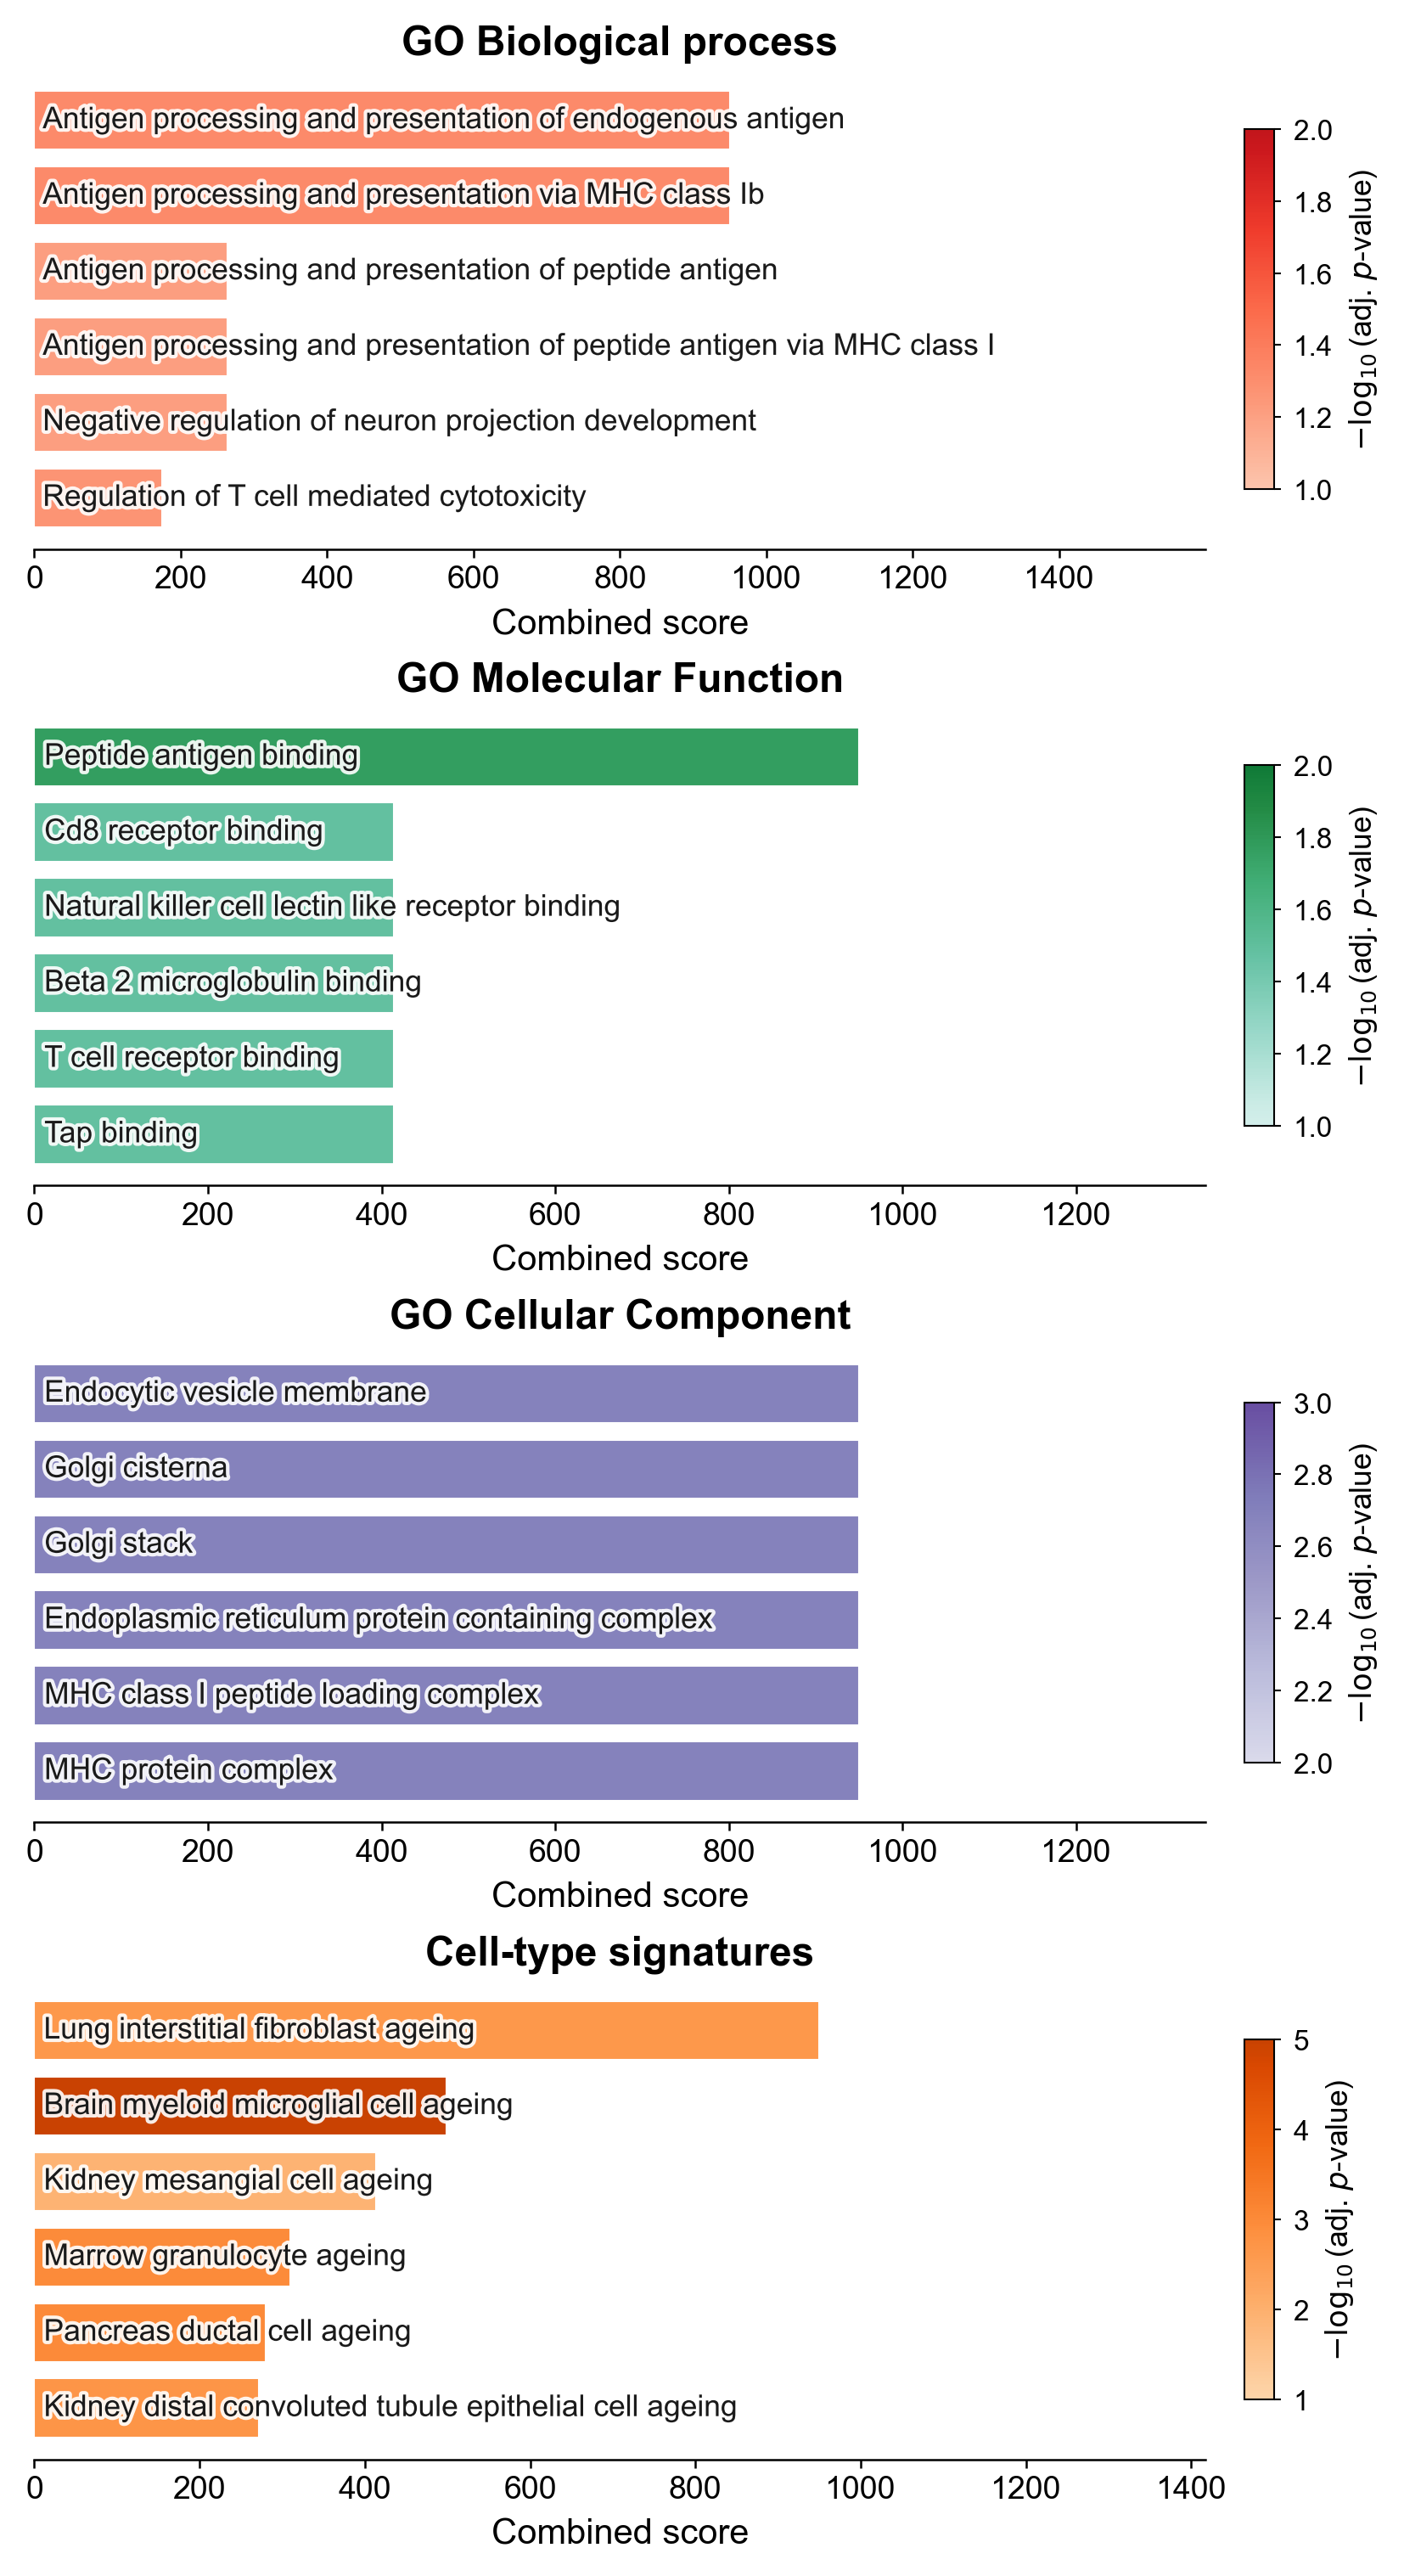

(PosixPath('Figures/Microglia/Microglia_stGP2_enrichment.png'),
 PosixPath('Figures/Microglia/Microglia_stGP2_enrichment.pdf'))

In [7]:
from plots import run_enrichment_for_program

if len(stgp2_positive_genes) < utils.MIN_POS_GENES:
    raise ValueError(
        f"{k_label} has only {len(stgp2_positive_genes)} positive genes "
        f"(< MIN_POS_GENES={utils.MIN_POS_GENES})"
    )

fig, enrichment_results = run_enrichment_for_program(
    gene_list=stgp2_positive_genes,
    background_genes=background_genes,
    gene_sets=gene_sets,
    padj_threshold=PADJ_THRESHOLD,
    n_top=N_TOP,
    title=f"{CELLTYPE} - {k_label}",
)

df_enrich = pd.concat(enrichment_results, ignore_index=True) if enrichment_results else pd.DataFrame()
if not df_enrich.empty:
    df_enrich.insert(0, "program", k_label)
    df_enrich.insert(1, "n_genes_input", len(stgp2_positive_genes))

display(df_enrich.head())
save_pair(fig, f"Microglia_{k_label}_enrichment", bbox_inches="tight", pad_inches=0.05)